# Task 5 — Time-Series Forecasting

## Objective

The objective of this task is to build an end-to-end time-series forecasting pipeline for daily demand data.

The analysis includes:

- Time-series exploration
- Trend, seasonality, and residual decomposition
- Augmented Dickey-Fuller (ADF) stationarity testing
- Differencing when required
- ARIMA/SARIMA forecasting
- Model evaluation using MAPE and RMSE
- 30-day future demand forecasting

## Dataset

The dataset contains daily demand observations along with marketing-event and holiday information.

The main forecasting variable is:

`demand`

In [1]:
# Import libraries and load the time-series dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

data_path = Path("../data/daily-demand-series.csv")

df = pd.read_csv(data_path)

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Rows: 30
Columns: 4

Column names:
['date', 'demand', 'marketing_event', 'holiday']

Missing values:
date               0
demand             0
marketing_event    0
holiday            0
dtype: int64

First 5 rows:


,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0


In [2]:
# Explore the time-series data

print("Date range:")
print("Start:", df["date"].min())
print("End:", df["date"].max())

print("\nDemand statistics:")
display(df["demand"].describe())

print("\nData types:")
print(df.dtypes)

print("\nTime-series frequency:")
print(df["date"].diff().value_counts())

print("\nFirst 10 observations:")
display(df.head(10))

Date range:
Start: 2026-06-01 00:00:00
End: 2026-06-30 00:00:00

Demand statistics:


count     30.000000
mean     142.100000
std       13.839848
min      118.000000
25%      132.500000
50%      142.000000
75%      150.250000
max      174.000000
Name: demand, dtype: float64


Data types:
date               datetime64[us]
demand                      int64
marketing_event             int64
holiday                     int64
dtype: object

Time-series frequency:
date
1 days    29
Name: count, dtype: int64

First 10 observations:


,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0
5,2026-06-06,151,1,0
6,2026-06-07,143,0,1
7,2026-06-08,126,0,0
8,2026-06-09,129,0,0
9,2026-06-10,132,0,0


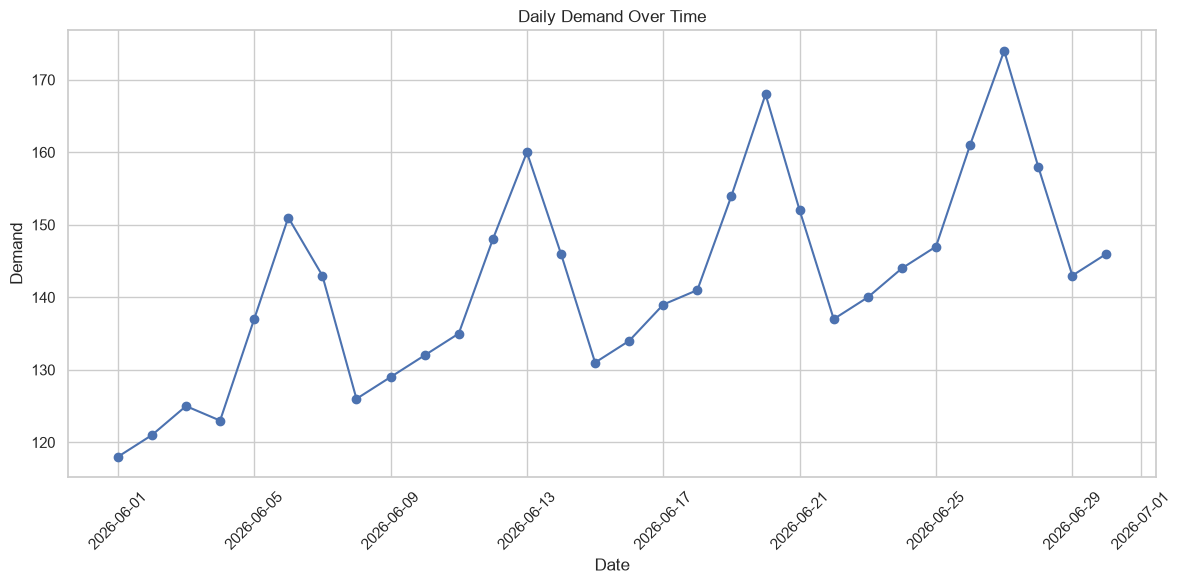

In [3]:
# Plot daily demand over time

plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["demand"],
    marker="o"
)

plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

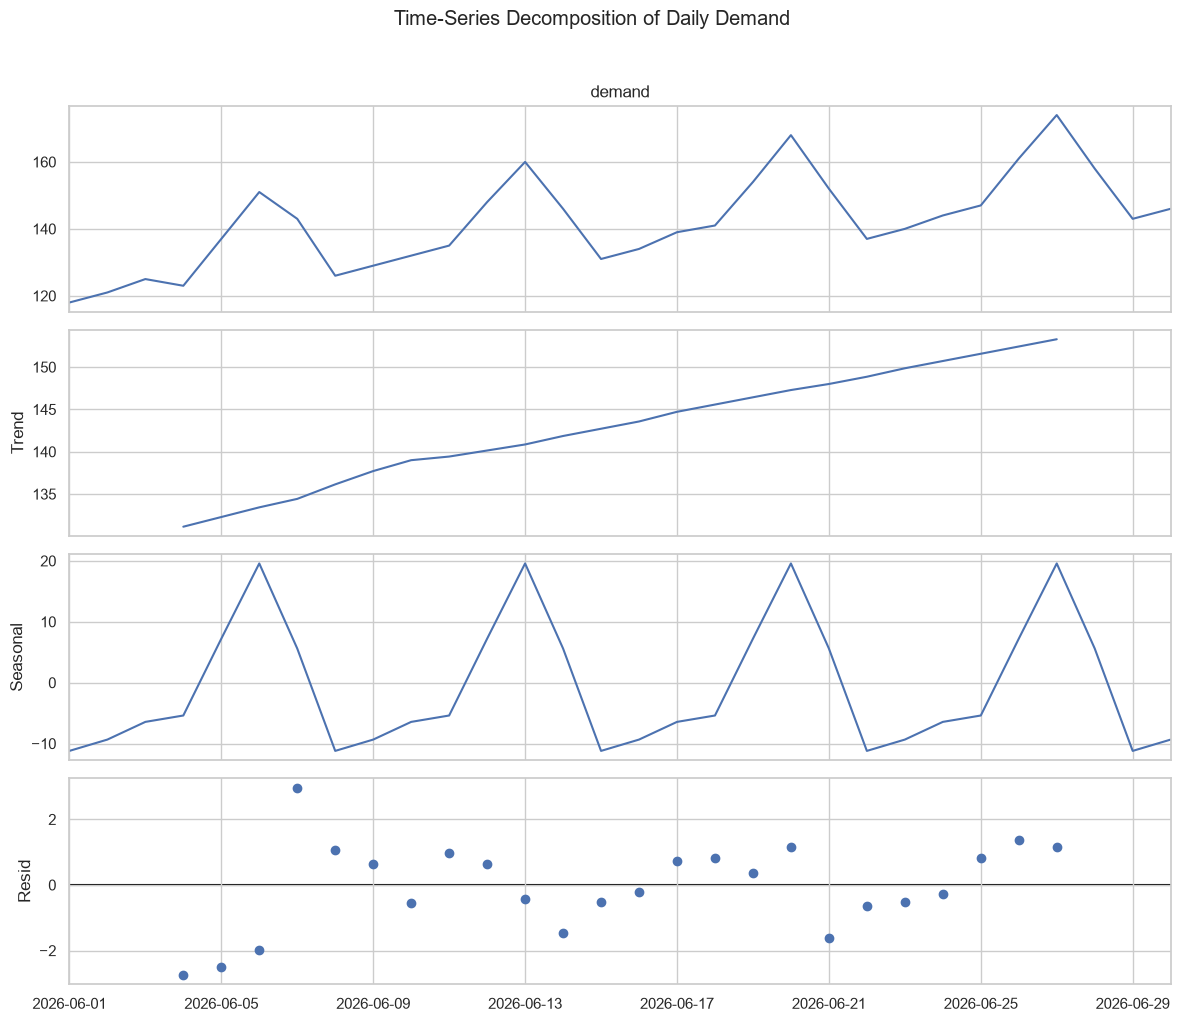

In [4]:
# Time-Series Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

demand_series = df.set_index("date")["demand"]

decomposition = seasonal_decompose(
    demand_series,
    model="additive",
    period=7
)

fig = decomposition.plot()

fig.set_size_inches(12, 10)
fig.suptitle("Time-Series Decomposition of Daily Demand", y=1.02)

plt.tight_layout()
plt.show()

In [5]:
# Augmented Dickey-Fuller (ADF) Stationarity Test

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(demand_series.dropna())

adf_statistic = adf_result[0]
adf_pvalue = adf_result[1]

print("Augmented Dickey-Fuller Test")
print("--------------------------------")
print("ADF Statistic:", round(adf_statistic, 4))
print("p-value:", round(adf_pvalue, 6))

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

if adf_pvalue < 0.05:
    print("\nDecision: Reject H₀")
    print("Conclusion: The demand series appears to be stationary.")
else:
    print("\nDecision: Fail to reject H₀")
    print("Conclusion: The demand series appears to be non-stationary.")

Augmented Dickey-Fuller Test
--------------------------------
ADF Statistic: -0.9039
p-value: 0.786695

Critical Values:
1%: -3.7697
5%: -3.0054
10%: -2.6425

Decision: Fail to reject H₀
Conclusion: The demand series appears to be non-stationary.


C:\Users\jaris\AppData\Local\Temp\ipykernel_9924\4030038043.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(demand_series.dropna())


In [6]:
# First-order differencing

demand_diff = demand_series.diff().dropna()

print("Differencing completed!")
print("Original observations:", len(demand_series))
print("Differenced observations:", len(demand_diff))

# ADF test after differencing
adf_diff_result = adfuller(demand_diff)

adf_diff_statistic = adf_diff_result[0]
adf_diff_pvalue = adf_diff_result[1]

print("\nADF Test After Differencing")
print("--------------------------------")
print("ADF Statistic:", round(adf_diff_statistic, 4))
print("p-value:", round(adf_diff_pvalue, 6))

if adf_diff_pvalue < 0.05:
    print("\nDecision: Reject H₀")
    print("Conclusion: The differenced series appears to be stationary.")
else:
    print("\nDecision: Fail to reject H₀")
    print("Conclusion: The differenced series may still be non-stationary.")

Differencing completed!
Original observations: 30
Differenced observations: 29

ADF Test After Differencing
--------------------------------
ADF Statistic: -2.2336
p-value: 0.194269

Decision: Fail to reject H₀
Conclusion: The differenced series may still be non-stationary.


C:\Users\jaris\AppData\Local\Temp\ipykernel_9924\3224715261.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff_result = adfuller(demand_diff)


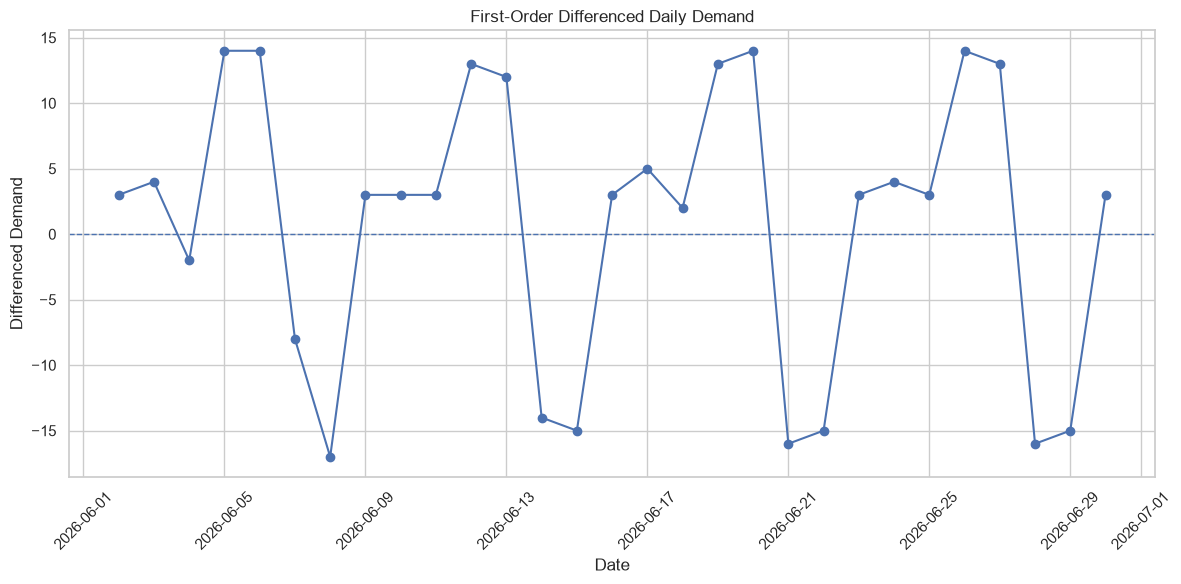

In [7]:
# Plot Differenced Demand Series

plt.figure(figsize=(12, 6))

plt.plot(
    demand_diff.index,
    demand_diff.values,
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("First-Order Differenced Daily Demand")
plt.xlabel("Date")
plt.ylabel("Differenced Demand")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# Train-Test Split for Time-Series Forecasting

split_index = int(len(demand_series) * 0.8)

train = demand_series.iloc[:split_index]
test = demand_series.iloc[split_index:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training observations: 24
Testing observations: 6

Training period:
2026-06-01 00:00:00 to 2026-06-24 00:00:00

Testing period:
2026-06-25 00:00:00 to 2026-06-30 00:00:00


In [9]:
# ARIMA(1,1,1) Model

from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train,
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(
    steps=len(test)
)

print("ARIMA(1,1,1) model fitted successfully!")
print("\nForecasted values:")
display(arima_forecast)

ARIMA(1,1,1) model fitted successfully!

Forecasted values:


C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2026-06-25    145.071592
2026-06-26    144.915111
2026-06-27    144.937962
2026-06-28    144.934625
2026-06-29    144.935112
2026-06-30    144.935041
Freq: D, Name: predicted_mean, dtype: float64

In [10]:
# Evaluate ARIMA Forecast

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

arima_mape = mean_absolute_percentage_error(
    test,
    arima_forecast
) * 100

arima_rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_forecast
    )
)

print("ARIMA(1,1,1) Evaluation")
print("------------------------")
print("MAPE:", round(arima_mape, 2), "%")
print("RMSE:", round(arima_rmse, 4))

ARIMA(1,1,1) Evaluation
------------------------
MAPE: 6.39 %
RMSE: 14.6209


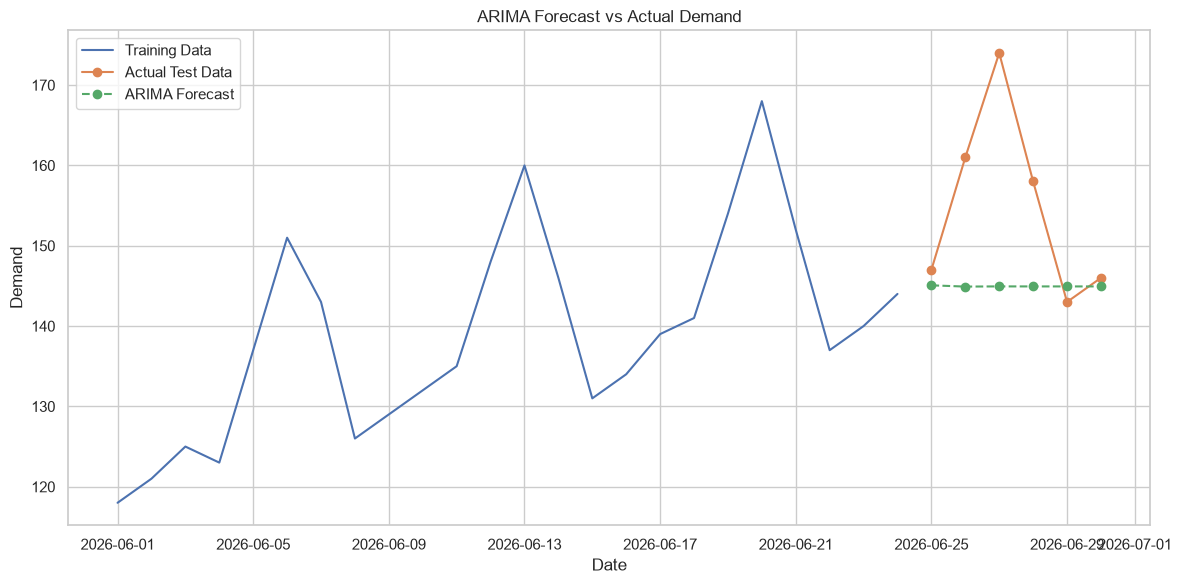

In [11]:
# Visualize ARIMA Forecast vs Actual Demand

plt.figure(figsize=(12, 6))

plt.plot(
    train.index,
    train.values,
    label="Training Data"
)

plt.plot(
    test.index,
    test.values,
    marker="o",
    label="Actual Test Data"
)

plt.plot(
    test.index,
    arima_forecast.values,
    marker="o",
    linestyle="--",
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# ARIMA Hyperparameter Selection

arima_results = []

orders = [
    (0, 1, 0),
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 0),
    (2, 1, 1)
]

for order in orders:
    try:
        model = ARIMA(
            train,
            order=order
        )

        fitted_model = model.fit()

        forecast = fitted_model.forecast(
            steps=len(test)
        )

        mape = mean_absolute_percentage_error(
            test,
            forecast
        ) * 100

        rmse = np.sqrt(
            mean_squared_error(
                test,
                forecast
            )
        )

        arima_results.append({
            "Order": str(order),
            "MAPE": mape,
            "RMSE": rmse
        })

    except Exception as e:
        print(f"ARIMA{order} failed: {e}")

arima_results_df = pd.DataFrame(arima_results)

arima_results_df = arima_results_df.sort_values(
    "RMSE"
).reset_index(drop=True)

display(arima_results_df)

C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: Val

,Order,MAPE,RMSE
0,"(1, 1, 0)",6.346822,14.485659
1,"(0, 1, 1)",6.329457,14.496601
2,"(1, 1, 1)",6.392775,14.620917
3,"(0, 1, 0)",6.795188,15.269796
4,"(2, 1, 0)",7.752457,17.173523
5,"(2, 1, 1)",8.347725,17.561914


In [13]:
# Select Best ARIMA Model

best_arima_order = tuple(
    int(x.strip())
    for x in arima_results_df.loc[0, "Order"]
    .strip("()")
    .split(",")
)

best_arima_order

(1, 1, 0)

In [14]:
# Fit the selected ARIMA model

best_arima_model = ARIMA(
    train,
    order=best_arima_order
)

best_arima_fit = best_arima_model.fit()

best_arima_forecast = best_arima_fit.forecast(
    steps=len(test)
)

print("Best ARIMA model fitted successfully!")
print("Selected order:", best_arima_order)

print("\nForecast:")
display(best_arima_forecast)

Best ARIMA model fitted successfully!
Selected order: (1, 1, 0)

Forecast:


C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2026-06-25    144.904700
2026-06-26    145.109320
2026-06-27    145.155601
2026-06-28    145.166068
2026-06-29    145.168435
2026-06-30    145.168971
Freq: D, Name: predicted_mean, dtype: float64

In [15]:
# SARIMA Model with Weekly Seasonality

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1, 1, 0),
    seasonal_order=(1, 0, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.forecast(
    steps=len(test)
)

print("SARIMA model fitted successfully!")
print("Order: (1, 1, 0)")
print("Seasonal Order: (1, 0, 0, 7)")

print("\nSARIMA Forecast:")
display(sarima_forecast)

C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMA model fitted successfully!
Order: (1, 1, 0)
Seasonal Order: (1, 0, 0, 7)

SARIMA Forecast:


C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


2026-06-25    146.210511
2026-06-26    159.332651
2026-06-27    173.505390
2026-06-28    157.313573
2026-06-29    142.134882
2026-06-30    145.170624
Freq: D, Name: predicted_mean, dtype: float64

In [16]:
# Evaluate SARIMA Forecast

sarima_mape = mean_absolute_percentage_error(
    test,
    sarima_forecast
) * 100

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_forecast
    )
)

print("SARIMA Evaluation")
print("------------------")
print("MAPE:", round(sarima_mape, 2), "%")
print("RMSE:", round(sarima_rmse, 4))

SARIMA Evaluation
------------------
MAPE: 0.58 %
RMSE: 0.9622


In [17]:
# Compare ARIMA and SARIMA

model_comparison = pd.DataFrame({
    "Model": [
        "Best ARIMA",
        "SARIMA"
    ],
    "MAPE": [
        mean_absolute_percentage_error(
            test,
            best_arima_forecast
        ) * 100,
        sarima_mape
    ],
    "RMSE": [
        np.sqrt(
            mean_squared_error(
                test,
                best_arima_forecast
            )
        ),
        sarima_rmse
    ]
})

model_comparison = model_comparison.sort_values(
    "RMSE"
).reset_index(drop=True)

display(model_comparison)

,Model,MAPE,RMSE
0,SARIMA,0.577406,0.962242
1,Best ARIMA,6.346822,14.485659


In [18]:
# Select the best forecasting model

best_model_name = model_comparison.loc[0, "Model"]

print("Selected Final Model:", best_model_name)
print("Selection Criterion: Lowest RMSE")

print("\nFinal Model Performance:")
display(model_comparison.iloc[[0]])

Selected Final Model: SARIMA
Selection Criterion: Lowest RMSE

Final Model Performance:


,Model,MAPE,RMSE
0,SARIMA,0.577406,0.962242


In [19]:
# Generate 30-Day Future Forecast

forecast_steps = 30

if best_model_name == "Best ARIMA":
    final_model = ARIMA(
        demand_series,
        order=best_arima_order
    )
    final_fit = final_model.fit()
    
    future_forecast = final_fit.forecast(
        steps=forecast_steps
    )

else:
    final_model = SARIMAX(
        demand_series,
        order=(1, 1, 0),
        seasonal_order=(1, 0, 0, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    final_fit = final_model.fit(disp=False)
    
    future_forecast = final_fit.forecast(
        steps=forecast_steps
    )

future_dates = pd.date_range(
    start=df["date"].max() + pd.Timedelta(days=1),
    periods=forecast_steps,
    freq="D"
)

forecast_df = pd.DataFrame({
    "date": future_dates,
    "forecast_demand": future_forecast.values
})

print("30-day forecast generated successfully!")

display(forecast_df)

C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


30-day forecast generated successfully!


,date,forecast_demand
0,2026-07-01,150.047789
1,2026-07-02,153.078278
2,2026-07-03,167.225629
3,2026-07-04,180.362244
4,2026-07-05,164.194066
5,2026-07-06,149.036393
6,2026-07-07,152.067928
7,2026-07-08,156.158265
8,2026-07-09,159.220608
9,2026-07-10,173.516669


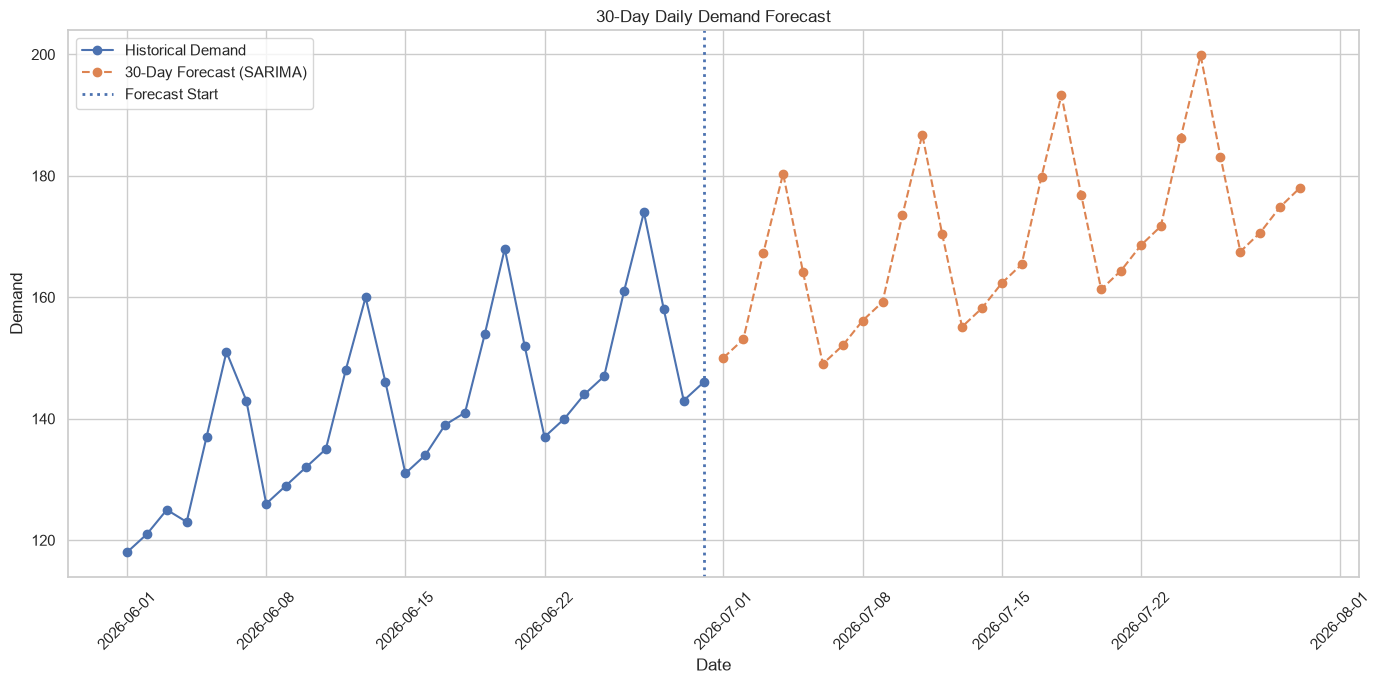

In [20]:
# Visualize 30-Day Demand Forecast

plt.figure(figsize=(14, 7))

plt.plot(
    df["date"],
    df["demand"],
    marker="o",
    label="Historical Demand"
)

plt.plot(
    forecast_df["date"],
    forecast_df["forecast_demand"],
    marker="o",
    linestyle="--",
    label=f"30-Day Forecast ({best_model_name})"
)

plt.axvline(
    x=df["date"].max(),
    linestyle=":",
    linewidth=2,
    label="Forecast Start"
)

plt.title("30-Day Daily Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
# Save Final Task 5 Results

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# Save model comparison
model_comparison.to_csv(
    results_dir / "task5_model_comparison.csv",
    index=False
)

# Save 30-day forecast
forecast_df.to_csv(
    results_dir / "task5_30_day_forecast.csv",
    index=False
)

print("Results saved successfully:")
print("- results/task5_model_comparison.csv")
print("- results/task5_30_day_forecast.csv")

Results saved successfully:
- results/task5_model_comparison.csv
- results/task5_30_day_forecast.csv


## Final Findings

### 1. Time-Series Decomposition
The daily demand series was decomposed into observed, trend, seasonal, and residual components using an additive decomposition with a 7-day seasonal period.

### 2. Stationarity
The Augmented Dickey-Fuller (ADF) test was applied to the original demand series. First-order differencing was then performed and the ADF test was repeated to assess whether stationarity improved.

### 3. Model Selection
Multiple ARIMA configurations were evaluated using the validation dataset. The models were compared using RMSE and MAPE.

The final forecasting model was selected based on the **lowest RMSE**.

### 4. SARIMA
A SARIMA model with weekly seasonality was also evaluated to determine whether seasonal information improved forecasting performance.

### 5. Forecast
The selected final model was refitted using the complete historical demand series and used to generate a **30-day future demand forecast**.

### 6. Evaluation Metrics
The forecasting models were evaluated using:

- **RMSE (Root Mean Squared Error)** — measures the magnitude of prediction errors.
- **MAPE (Mean Absolute Percentage Error)** — measures prediction error as a percentage.

### Conclusion
The analysis demonstrates a complete time-series forecasting workflow including data exploration, decomposition, stationarity testing, differencing, ARIMA/SARIMA modelling, hyperparameter comparison, model evaluation, and 30-day future forecasting.